<div style="background-color: black; color: white; padding: 10px;text-align: center;">
  <strong>Date Published:</strong> Sep 18, 2026 <strong>Author:</strong> Adnan Alaref
</div>

# **English → Arabic Translation with a Transformer**

Transformers changed modern NLP by replacing recurrence with **attention**, allowing models to capture relationships between words regardless of their distance.

In this notebook, I take that idea from **theory to a complete working system**: building a Transformer **from scratch in PyTorch**, training it on an English–Arabic parallel dataset, and analyzing its translation performance.

> **Not just using a Transformer — understanding what happens inside it.**

# **Previous Work & Resources**

Before building this English → Arabic Translation Transformer, I developed the following notebooks to progressively understand the key concepts behind the model.

| Type | Previous Work / Resource | Role in This Notebook |
|------|--------------------------|------------------------|
| 📘 Notebook 1 | [Attention Mechanisms: Journey from Fixed to Cross](https://www.kaggle.com/code/adnanalaref/attention-mechanisms-journey-from-fixed-to-cross) | Understanding attention mechanisms, from fixed attention to cross-attention |
| 📘 Notebook 2 | [How Transformers Know Where Words Are (PE)](https://www.kaggle.com/code/adnanalaref/how-transformers-know-where-words-are-pe) | Understanding positional encoding and how Transformers represent word positions |
| 📘 Notebook 3 | [Transformer From Scratch: No Black Boxes](https://www.kaggle.com/code/adnanalaref/transformer-from-scratch-no-black-boxes) | Building and understanding the Transformer architecture from scratch |
| 📂 Dataset | [English-Arabic Parallel Text Dataset](https://www.kaggle.com/datasets/adnanalaref/english-arabic-parallel-text-dataset) | English–Arabic parallel text used to train and evaluate the translation model |

### **Learning Path**

**Attention → Positional Encoding → Transformer From Scratch → English–Arabic Translation**

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 1: Import Library.</div>

In [28]:
import os
import math
import torch
import random
import numpy as np
import pandas as pd
import torch.nn as nn
from pprint import pprint
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from typing import Callable,Tuple,Dict,Any,List
from torch.utils.data import DataLoader, Dataset

import warnings
warnings.simplefilter(action= "ignore")
warnings.filterwarnings(action= "ignore", category=FutureWarning)

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 2: Prepare a Vocabulary.</div>

In [29]:
class Vocabulary:
  def __init__(self, sentences: List[str], is_target: bool = False)->None:
    """
      Build a vocabulary from a list of sentences.

      Args:
        sentences: Sentences used to build the vocabulary.
        is_target: Whether this vocabulary belongs to the target language.
                   Target vocabularies use BOS and EOS tokens.
    """

    self.is_target = is_target

    # ── Special tokens used by the source vocabulary.
    self.PAD_TOKEN = "<PAD>"
    self.UNK_TOKEN = "<UNK>"

    special_tokens = [
      self.PAD_TOKEN,
      self.UNK_TOKEN,
    ]

    if is_target:
      # ── Special tokens used by the target vocabulary.
      self.BOS_TOKEN = "<BOS>"
      self.EOS_TOKEN = "<EOS>"

      special_tokens.extend([
        self.BOS_TOKEN,
        self.EOS_TOKEN
      ])

    # ── Extract all unique words while preserving their order.
    unique_words = dict.fromkeys(
      " ".join(sentences).split()
    )

    # ── Build vocabulary
    self.words = [
      *special_tokens,
      *[
        word
        for word in unique_words
        if word not in special_tokens
      ]
    ]

    # ── Map each word to its integer index.
    self.word_to_idx = {
      word : idx
      for idx, word in enumerate(self.words)
    }

    # ── Map each integer index back to its corresponding word.
    self.idx_to_word = {
      idx : word
      for word, idx in self.word_to_idx.items()
    }

    # ── Store special-token indices for convenient access.
    self.PAD_IDX = self.word_to_idx[self.PAD_TOKEN]
    self.UNK_IDX = self.word_to_idx[self.UNK_TOKEN]

    if is_target:
      self.BOS_IDX = self.word_to_idx[self.BOS_TOKEN]
      self.EOS_IDX = self.word_to_idx[self.EOS_TOKEN]


  def __len__(self)-> int:
    """Return the total number of tokens in the vocabulary."""
    return len(self.words)


  def __contains__(self, word: str) -> bool:
    """Return True if the word exists in the vocabulary."""
    return word in self.word_to_idx


  def sentence_to_indices(self, sentence: str)->List[int]:
    """
      Convert a sentence into token indices.

      Target sentences automatically receive BOS and EOS tokens.
      Unknown words are mapped to UNK_IDX.
    """
    tokens = sentence.split()

    if self.is_target:
      tokens = [
        self.BOS_TOKEN,
        *tokens,
        self.EOS_TOKEN
      ]

    encoded = [
      self.word_to_idx.get(
        token,
        self.UNK_IDX
      )
      for token in tokens
    ]

    return encoded


  def indices_to_sentence(
    self,
    indices: List[int],
    ignore_invalid: bool = True,
    remove_special_tokens: bool = True
    ) -> str:
    """
      Convert token indices back into a sentence.

      For target sequences, decoding stops at EOS.
      PAD and BOS tokens are optionally removed.
      Invalid indices have two choices
        1- Ignored
        2- raise `ValueError` for debug perpose
          because they should not normally appear in a valid encoded sequence.
    """
    words = []

    for idx in indices:

      # ── Stop when the target sequence reaches EOS.
      if self.is_target and idx == self.EOS_IDX:
        break

      # Skip padding and BOS during text reconstruction.
      if remove_special_tokens:
        if idx == self.PAD_IDX:
          continue

        if self.is_target and idx == self.BOS_IDX:
          continue

      # Ignore invalid indices.
      if idx not in self.idx_to_word:
        if ignore_invalid:
          continue

        else:
          raise ValueError(f"Invalid token index: {idx}")

      words.append(self.idx_to_word[idx])

    return " ".join(words)


  def encode(self, sentences: List[str])->List[List[int]]:
    """
      Convert a list of sentences into sequences of token IDs.
      Each sentence is tokenized into words, and each word is
      mapped to its corresponding ID in the vocabulary.
    """
    all_encoded = []

    for sent in sentences:
      all_encoded.append(self.sentence_to_indices(sent))

    return all_encoded


  def decode(self, encoded_sentences: List[List[int]])->List[List[str]]:
    """
      Convert a list of token-ID sequences back into words.
      Each sequence of token IDs is mapped to its corresponding
        words using the reverse vocabulary mapping.
    """
    all_decoded = []

    for sent in encoded_sentences:
      all_decoded.append(self.indices_to_sentence(sent))

    return all_decoded

  def save(self, path:str)->None:
    """Save the vocabulary state to disk."""
    data = {
      "words": self.words,
      "word_to_idx": self.word_to_idx,
      "is_target": self.is_target,
      "PAD_TOKEN": self.PAD_TOKEN,
      "UNK_TOKEN": self.UNK_TOKEN,
    }

    if self.is_target:
      data.update({
        "BOS_TOKEN":self.BOS_TOKEN,
        "EOS_TOKEN": self.EOS_TOKEN
      })

    # Create dir
    os.makedirs(os.path.dirname(path), exist_ok=True)
    print(f"Saved Vocabulary: {path}")
    torch.save(data,path)


  @classmethod
  def load(cls, path:str)-> "Vocabulary":
    """Load a previously saved vocabulary from disk."""

    data = torch.load(path)

    # Create an instance without calling __init__.
    vocab = cls.__new__(cls)

    # ── Restore basic state ──────────────
    vocab.is_target = data["is_target"]

    vocab.words = data["words"]
    vocab.word_to_idx = data["word_to_idx"]

    # Rebuild the reverse mapping.
    vocab.idx_to_word = {
        idx: word
        for word, idx in vocab.word_to_idx.items()
    }

    # ── Restore special tokens ───────────
    vocab.PAD_TOKEN = data["PAD_TOKEN"]
    vocab.UNK_TOKEN = data["UNK_TOKEN"]

    vocab.PAD_IDX = vocab.word_to_idx[vocab.PAD_TOKEN]
    vocab.UNK_IDX = vocab.word_to_idx[vocab.UNK_TOKEN]

    if vocab.is_target:
      vocab.BOS_TOKEN = data["BOS_TOKEN"]
      vocab.EOS_TOKEN = data["EOS_TOKEN"]

      vocab.BOS_IDX = vocab.word_to_idx[vocab.BOS_TOKEN]
      vocab.EOS_IDX = vocab.word_to_idx[vocab.EOS_TOKEN]

    return vocab

In [30]:
# Example sentences
sentences = [
  "I love machine learning",
  "I love deep learning",
  "I enjoy coding in Python",
  "Python is great for AI",
]

vocab = Vocabulary(sentences)
print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 15


In [31]:
print(vocab.words)
print(vocab.word_to_idx)
print(vocab.idx_to_word)

['<PAD>', '<UNK>', 'I', 'love', 'machine', 'learning', 'deep', 'enjoy', 'coding', 'in', 'Python', 'is', 'great', 'for', 'AI']
{'<PAD>': 0, '<UNK>': 1, 'I': 2, 'love': 3, 'machine': 4, 'learning': 5, 'deep': 6, 'enjoy': 7, 'coding': 8, 'in': 9, 'Python': 10, 'is': 11, 'great': 12, 'for': 13, 'AI': 14}
{0: '<PAD>', 1: '<UNK>', 2: 'I', 3: 'love', 4: 'machine', 5: 'learning', 6: 'deep', 7: 'enjoy', 8: 'coding', 9: 'in', 10: 'Python', 11: 'is', 12: 'great', 13: 'for', 14: 'AI'}


In [32]:
path = r'/kaggle/working/Vocabulary/vocab.pt'
vocab.save(path=path)

Saved Vocabulary: /kaggle/working/Vocabulary/vocab.pt


In [33]:
loaded_vocab = vocab.load(path)
print(loaded_vocab.words)
print(loaded_vocab.word_to_idx)
print(loaded_vocab.idx_to_word)

['<PAD>', '<UNK>', 'I', 'love', 'machine', 'learning', 'deep', 'enjoy', 'coding', 'in', 'Python', 'is', 'great', 'for', 'AI']
{'<PAD>': 0, '<UNK>': 1, 'I': 2, 'love': 3, 'machine': 4, 'learning': 5, 'deep': 6, 'enjoy': 7, 'coding': 8, 'in': 9, 'Python': 10, 'is': 11, 'great': 12, 'for': 13, 'AI': 14}
{0: '<PAD>', 1: '<UNK>', 2: 'I', 3: 'love', 4: 'machine', 5: 'learning', 6: 'deep', 7: 'enjoy', 8: 'coding', 9: 'in', 10: 'Python', 11: 'is', 12: 'great', 13: 'for', 14: 'AI'}


In [34]:
# Recreate vocabulary with UNK tokens
vocab_test = Vocabulary(sentences)

# Now test the same sentence that crashed before
test_sentence = "I love quantum computing"

try:
  indices = vocab_test.sentence_to_indices(test_sentence)
  print("SUCCESS!\n",f"Encoded as: {indices}")
  print(f" Decoded as: {vocab_test.indices_to_sentence(indices)}")
except KeyError as e:
  print(f"Still broken: {e}")

SUCCESS!
 Encoded as: [2, 3, 1, 1]
 Decoded as: I love <UNK> <UNK>


# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 3: Create a Custom Dataset.</div>

In [35]:
src_path = r"/kaggle/input/datasets/adnanalaref/english-arabic-parallel-text-dataset/nature_english.txt"
tgt_path = r"/kaggle/input/datasets/adnanalaref/english-arabic-parallel-text-dataset/nature_arabic.txt"

In [36]:
def preprocess_languages(
  eng_data_path: str,
  arb_data_path: str
  )->tuple[List[str], List[str]]:

  """
    Read aligned English and Arabic sentences from text files.
    Each line in both files represents one translation pair.
  """

  with open(file=eng_data_path, mode='r', encoding='utf-8') as eng_file:
    eng_data = [line.strip() for line in eng_file]

  with open(file=arb_data_path, mode='r', encoding='utf-8') as arb_file:
    arb_data = [line.strip() for line in arb_file]

  if len(eng_data) != len(arb_data):
    raise ValueError(
      "English and Arabic files must contain the same number "
      "of sentences."
    )

  return eng_data, arb_data

def build_samples(source_path: str,
                  target_path: str
                  )->Tuple[List[List[int]], List[List[int]], Vocabulary, Vocabulary]:
  """
    Build encoded source and target samples and their vocabularies.
  """

  source_sentences, target_sentences = preprocess_languages(
        source_path,
        target_path
  )

  source_vocab = Vocabulary(source_sentences)
  target_vocab = Vocabulary(
    target_sentences,
    is_target=True
  )

  source_samples = source_vocab.encode(source_sentences)
  target_samples = target_vocab.encode(target_sentences)

  return (
    source_samples,
    target_samples,
    source_vocab,
    target_vocab
  )

In [37]:
class TranslationDataset(Dataset):
  def __init__(self, source_path: str, target_path: str) -> None:
    super().__init__()

    (
      self.source_samples,
      self.target_samples,
      self.source_vocab,
      self.target_vocab
    ) = build_samples(
      source_path,
      target_path
    )


    if len(self.source_samples) != len(self.target_samples):
      raise ValueError(
        "Source and target must contain the same number "
        "of samples."
      )

  def __len__(self)->int:
    """Return the number of translation pairs."""
    return len(self.source_samples)

  @property
  def source_lengths(self) -> List[int]:
    """
      Return a list containing the length of each source sequence.

      The source sequences form a jagged/ragged list because each
      sequence may have a different number of tokens.
    """
    return [
      len(sentence)
      for sentence in self.source_samples
    ]

  @property
  def target_lengths(self) -> List[int]:
    """
      Return a list containing the length of each target sequence.

      The target sequences form a jagged/ragged list because each
      sequence may have a different number of tokens.
    """
    return [
      len(sentence)
      for sentence in self.target_samples
    ]

  @property
  def is_empty(self)-> bool:
    """Return whether the dataset contains no samples."""
    return len(self) == 0

  def __getitem__(self, index)->Tuple[List[int], List[int]]:
    """Return one source-target translation pair."""
    return (
      self.source_samples[index],
      self.target_samples[index]
    )

  def summary(self)-> pd.DataFrame:
    """Return basic dataset statistics as a table."""

    return pd.DataFrame({
        "Dataset": ["Source", "Target"],
        "Samples": [
            len(self.source_samples),
            len(self.target_samples)
        ],
        "Min Length": [
            min(self.source_lengths),
            min(self.target_lengths)
        ],
        "Max Length": [
            max(self.source_lengths),
            max(self.target_lengths)
        ]
    })

# ── Load translation dataset and vocabularies ──
translation_dataset = TranslationDataset(src_path, tgt_path)

# ── Get vocabularies from the dataset ──
src_vocab = translation_dataset.source_vocab
tgt_vocab = translation_dataset.target_vocab

# ── Define vocabulary file paths ──
src_path = r'/kaggle/working/Vocabulary/src_vocab.pt'
tgt_path = r'/kaggle/working/Vocabulary/tgt_vocab.pt'

# ── Save source and target vocabularies ──
src_vocab.save(src_path)
tgt_vocab.save(tgt_path)

Saved Vocabulary: /kaggle/working/Vocabulary/src_vocab.pt
Saved Vocabulary: /kaggle/working/Vocabulary/tgt_vocab.pt


In [38]:
print("Translation Dataset")
print(f"  Number of samples : {len(translation_dataset)}")
print(f"  Is empty          : {translation_dataset.is_empty}")
print(f"  Source lengths    : {translation_dataset.source_lengths}")
print(f"  Target lengths    : {translation_dataset.target_lengths}")

Translation Dataset
  Number of samples : 15
  Is empty          : False
  Source lengths    : [4, 12, 17, 14, 15, 14, 15, 19, 16, 16, 19, 14, 15, 17, 15]
  Target lengths    : [4, 11, 15, 14, 11, 16, 17, 17, 14, 14, 19, 15, 12, 15, 15]


In [39]:
print("Source samples (first 5):")
pprint(translation_dataset.source_samples[:5])

print("\nTarget samples (first 5):")
pprint(translation_dataset.target_samples[:5])

Source samples (first 5):
[[2, 3, 4, 5],
 [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [18, 19, 20, 21, 22, 23, 24, 19, 25, 26, 27, 19, 28, 8, 29, 30, 31],
 [32, 33, 34, 24, 19, 35, 36, 37, 38, 39, 40, 41, 19, 42],
 [43, 44, 19, 45, 46, 47, 48, 26, 8, 49, 50, 51, 52, 19, 53]]

Target samples (first 5):
[[2, 4, 5, 3],
 [2, 6, 4, 7, 8, 9, 10, 11, 12, 13, 3],
 [2, 11, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 3],
 [2, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 3],
 [2, 38, 39, 40, 41, 42, 43, 44, 45, 37, 3]]


# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 4: Setup Confiureations.</div>

In [40]:
# Instead of hardcoded values, use config
from dataclasses import dataclass

@dataclass
class ModelConfig:
  tgt_vocab_size: int | None = None
  src_vocab_size:int | None = None
  max_seq_len: int = 32
  d_model: int = 128
  expansion_dim: int = 512
  num_heads: int = 4
  num_layers: int = 2
  dropout: float = 0.1
  pad_idx: int | None = None

  def __post_init__(self):
    if self.src_vocab_size is None:
      self.src_vocab_size = len(src_vocab)

    if self.tgt_vocab_size is None:
      self.tgt_vocab_size = len(tgt_vocab)

    if self.pad_idx is None:
      self.pad_idx = src_vocab.PAD_IDX

@dataclass
class TrainingConfig:
  device: torch.device | None = None
  batch_size: int = 2
  eps: float = 1e-9
  epochs: int = 100
  print_every: int = 10
  betas: tuple =(0.9, 0.98)
  warmup_steps:int = 100 #  B = 15 / 2 = 8 -> increase → peak(W_up/B) → decrease 
  learning_rate: float = 1.0 # actual LR=initial LR×LambdaLR multiplier
  save_every: int = 10    # save checkpoint every 10 epochs
  checkpoint_path: str = r'/kaggle/working/checkpoints'

  def __post_init__(self):
    if self.device is None:
      self.device = torch.device(
        "mps"
        if torch.backends.mps.is_available()
        else "cuda"
        if torch.cuda.is_available()
        else "cpu"
      )

config = ModelConfig()
train_cfg = TrainingConfig()

In [41]:
def save_checkpoints(model: nn.Module, scaler: torch.cuda.amp.GradScaler|None,
                     optimizer: torch.optim.Optimizer, train_loss: float, train_acc: float, epoch: int, path: str)->None:
  # Define Chekpoint
  checkpoint = {
    "epoch": epoch,
    "train_loss": float(train_loss),
    "train_acc": float(train_acc),
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict()
  }

  # add scaler ONLY if it exists
  if scaler is not None:
    checkpoint['scaler_state_dict'] = scaler.state_dict()

  # Create dir
  os.makedirs(os.path.dirname(path), exist_ok=True)
  torch.save(checkpoint, path)


def load_checkpoint(path:str, device: str|None=None)->dict:
  if not os.path.isfile(path):
    raise FileNotFoundError(f"Checkpoint file does not found.\nPath: {path}")

  # Load Data
  checkpoint_data = torch.load(path, map_location=device)
  return checkpoint_data

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 5: Create a DataLoader.</div>

In [42]:
def custom_collate_fn(batch):
  """
    Collate variable-length translation samples into padded batch tensors.

    Each sample contains a source and target sequence represented as
    lists of token IDs. Source and target sequences are padded
    independently to the maximum length found in the current batch.

    Args:
        batch: A list of `(source_sequence, target_sequence)` pairs.

    Returns:
        A tuple containing:
            source_tensor: Padded source token IDs with shape
                `(batch_size, max_source_length)`.
            target_tensor: Padded target token IDs with shape
                `(batch_size, max_target_length)`.
  """

  # ── Batch size ──
  B = len(batch)

  # ── Get padding index ──
  pad_idx = config.pad_idx

  # ── Separate source and target sequences ──
  source_sequences, target_sequences = zip(*batch)

  # ── Find maximum sequence lengths ──
  max_src = max(map(len, source_sequences))
  max_tgt = max(map(len, target_sequences))

  # ── Create PAD-filled tensors ──
  source_tensor = torch.full(
    size=(B, max_src),
    dtype=torch.long,
    fill_value=pad_idx
  )

  target_tensor = torch.full(
    size=(B, max_tgt),
    dtype=torch.long,
    fill_value=pad_idx
  )

  # ── Copy real token IDs ──
  for i, (src_sequence, tgt_sequence) in enumerate(batch):
    source_tensor[i, :len(src_sequence)] = torch.tensor(
      src_sequence,
      dtype=torch.long
    )

    target_tensor[i, :len(tgt_sequence)] = torch.tensor(
      tgt_sequence,
      dtype=torch.long
    )

  # ── Return padded tensors ──
  return source_tensor, target_tensor



# ── Create DataLoader ──────────────────────────────

# Number of worker processes used for data loading
# > 0 enables parallel data loading
num_workers = min(4, os.cpu_count() or 1)

# Pin memory is only useful when training on CUDA
# It speeds up CPU → GPU memory transfers
pin_memory = train_cfg.device == "cuda"

loader_kwargs = dict(
  num_workers = num_workers,
  pin_memory = pin_memory,
  persistent_workers = num_workers > 0,
  # persistent_workers Keeps worker processes alive between epochs
  # Must be False when num_workers == 0
)

# prefetch_factor controls how many batches each worker preloads
# It is only valid when num_workers > 0
if num_workers > 0:
    loader_kwargs["prefetch_factor"] = 2


dataloader = DataLoader(dataset = translation_dataset,
                        batch_size= train_cfg.batch_size,
                        collate_fn=custom_collate_fn,
                        shuffle = True,
                        **loader_kwargs)

In [43]:
src_tensor, tgt_tensor = next(iter(dataloader))
src_tensor.shape, tgt_tensor.shape

(torch.Size([2, 16]), torch.Size([2, 14]))

In [44]:
print(f"Number of batches: {len(dataloader)}")
translation_dataset.summary()

Number of batches: 8


,Dataset,Samples,Min Length,Max Length
0,Source,15,4,19
1,Target,15,4,19


# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 6: Model Architecture Design.</div>

In [45]:
# ==============================================================================
# Multi-Head Attention
# ==============================================================================
class MultiHeadAttention(nn.Module):
  def __init__(self, d_model: int, num_heads: int) -> None:
    super(MultiHeadAttention, self).__init__()

    # ── Initialize dimensions ─────────────────────────────────────────────────
    self.d_model = d_model # Model's dimension
    self.num_heads = num_heads # Number of attention heads
    self.head_dim = d_model // num_heads # Dimension of each head's key, query, and value

    # ── Scaling factor ────────────────────────────────────────────────────────
    self.scale = self.head_dim ** 0.5

    # Ensure that the model dimension (d_model) is divisible by the number of heads
    if self.head_dim * num_heads != d_model:
      raise ValueError(
        f"Embedding_dim ({d_model}) must be divisible by num heads ({num_heads})."
      )

    # ── Linear projections ────────────────────────────────────────────────────
    self.W_q = nn.Linear(d_model, d_model)
    self.W_k = nn.Linear(d_model, d_model)
    self.W_v = nn.Linear(d_model, d_model)

    # ── Output projection ─────────────────────────────────────────────────────
    self.fc_proj = nn.Linear(d_model, d_model)


  def split_heads(self, M: torch.Tensor)-> torch.Tensor:
    """
      Split the embedding dimension into multiple attention heads.
      Input:
          M: (B, seq_len, d_model)
      Output:
          M: (B, num_heads, seq_len, head_dim)
    """

    B, seq_len, _ = M.shape
    return M.view(
      B,
      seq_len,
      self.num_heads,
      self.head_dim).transpose(1,2)


  def combine_heads(self, M: torch.Tensor)-> torch.Tensor:
    """
      Combine multiple attention heads.
      Input:
          M: (B, num_heads, seq_len, head_dim)
      Output:
        M: (B, seq_len, d_model)
    """

    B, _, seq_len, _ = M.shape
    return M.transpose(1,2).reshape(
      B,
      seq_len,
      self.d_model
    )

  def scaled_dot_product_attention(self,
                                   query: torch.Tensor,
                                   key: torch.Tensor,
                                   value: torch.Tensor,
                                   mask: torch.Tensor | None = None,
                                   )-> torch.Tensor:

    """Compute scaled dot-product attention."""

    # ── QKᵀ / √dₖ ─────────────────────────────────────────────────────────────
    attn_scores = torch.matmul(
      query,
      key.transpose(-2,-1)
    ) / self.scale

    # ── Apply mask ────────────────────────────────────────────────────────────
    if mask is not None:
      attn_scores = attn_scores.masked_fill(
        ~mask,
        float("-inf")
      )

    # ── Convert scores → probabilities ────────────────────────────────────────
    attn_weights = F.softmax(
      attn_scores,
      dim=-1
    )

    # ── Weighted sum of values ────────────────────────────────────────────────
    output = torch.matmul(
      attn_weights,
      value
    )

    return output


  def forward(self,
              Q: torch.Tensor,
              K: torch.Tensor,
              V: torch.Tensor,
              mask: torch.Tensor | None = None
              )->torch.Tensor:
    """
      Multi-head attention.
      Architecture:
            Projection → Split → Attention → Combine → Projection
    """

    # ── Linear projections ────────────────────────────────────────────────────
    query = self.W_q(Q)
    key = self.W_k(K)
    value = self.W_v(V)

    # ── Split into attention heads ────────────────────────────────────────────
    query = self.split_heads(query)
    key = self.split_heads(key)
    value = self.split_heads(value)

    # ── Scaled dot-product attention ──────────────────────────────────────────
    attn_output = self.scaled_dot_product_attention(
      query,
      key,
      value,
      mask
    )

    # ── Combine heads ─────────────────────────────────────────────────────────
    output = self.combine_heads(
      attn_output
    )

    # ── Output projection ─────────────────────────────────────────────────────
    return self.fc_proj(
      output
    )


# ==============================================================================
# Positional Encoding
# ==============================================================================
class PositionalEncoding(nn.Module):
  """
    Generate sinusoidal positional encodings for Transformer inputs.

    PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
  """

  def __init__(self, max_seq_len: int, d_model: int) -> None:
    super(PositionalEncoding, self).__init__()

    if d_model % 2 != 0:
      raise ValueError(
        "d_model must be even to pair sine and cosine dimensions "
        "as in the original Transformer paper."
      )

    PE = torch.zeros(max_seq_len, d_model)

    pos = torch.arange(max_seq_len)[:, None]

    i = torch.arange(0, d_model, 2)

    div_term = torch.exp(-( i / d_model) * math.log(10_000))

    angle = pos * div_term

    PE[:, 0::2] = torch.sin(angle)
    PE[:, 1::2] = torch.cos(angle)

    self.register_buffer("PE", PE)

  def forward(self, x: torch.Tensor)-> torch.Tensor:
    seq_len = x.shape[1]
    return x + self.PE[:seq_len]


# ==============================================================================
# Position-wise Feed-Forward Network
# ==============================================================================
class PositionWiseFeedForward(nn.Module):
  """
    Position-wise feed-forward network used in the Transformer.

    Applies two linear projections with a non-linear activation
    independently to each token position.
  """

  def __init__(self, d_model: int, expansion_dim: int) -> None:
    super().__init__()

    self.fc1_proj = nn.Linear(d_model, expansion_dim)
    self.fc2_proj = nn.Linear(expansion_dim, d_model)
    self.relu = nn.ReLU()

  def forward(self, x:torch.Tensor)-> torch.Tensor:
    return self.fc2_proj(
      self.relu(
        self.fc1_proj(x)
      )
    )



# ==============================================================================
# Encoder Layer
# ==============================================================================
class EncoderLayer(nn.Module):
  """
    Transformer encoder layer using Post-LayerNorm.

    Steps:
       1. Self-attention:
           x = LayerNorm(x + Dropout(Self-Attention(x)))

       2. Position-wise feed-forward network:
           x = LayerNorm(x + Dropout(FFN(x)))
  """

  def __init__(self,
               d_model: int,
               num_heads: int,
               expansion_dim: int,
               dropout_prop: float) -> None:

    super().__init__()

    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)

    self.dropout = nn.Dropout(dropout_prop)

    self.self_attn = MultiHeadAttention(d_model, num_heads)
    self.feed_forward = PositionWiseFeedForward(d_model, expansion_dim)

  def forward(
      self,
      x: torch.Tensor,
      mask: torch.Tensor | None = None
    )-> torch.Tensor:

    # ── Self-Attention ──
    attn_output = self.self_attn(x, x, x, mask)
    x = self.norm1(x + self.dropout(attn_output))

    # ── Feed-Forward Network ──
    ffn_output = self.feed_forward(x)
    x = self.norm2(x + self.dropout(ffn_output))

    return x


# ==============================================================================
# Decoder Layer
# ==============================================================================
class DecoderLayer(nn.Module):
  """
    Transformer decoder layer using Post-LayerNorm.

    Steps:
        1. Masked self-attention:
           x = LayerNorm(x + Dropout(Self-Attention(x, x, x, tgt_mask)))

        2. Cross-attention:
           x = LayerNorm(x + Dropout(Cross-Attention(x, enc_output, enc_output, src_mask)))

        3. Position-wise feed-forward network:
           x = LayerNorm(x + Dropout(FFN(x)))
  """
  def __init__(self,
               d_model: int,
               num_heads: int,
               expansion_dim: int,
               dropout_prop: float) -> None:
    super().__init__()

    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)
    self.norm3 = nn.LayerNorm(d_model)

    self.dropout = nn.Dropout(dropout_prop)

    self.self_attn = MultiHeadAttention(d_model, num_heads)
    self.cross_attn = MultiHeadAttention(d_model, num_heads)
    self.feed_forward = PositionWiseFeedForward(d_model, expansion_dim)

  def forward(
      self,
      x: torch.Tensor,
      enc_output: torch.Tensor,
      src_mask: torch.Tensor,
      tgt_mask: torch.Tensor
    )-> torch.Tensor:

    # ── Masked Self-Attention ──
    attn_output = self.self_attn(x, x, x, tgt_mask)
    x = self.norm1(x + self.dropout(attn_output))

    # ── Cross-Attention ──
    attn_output = self.cross_attn(x, enc_output, enc_output, src_mask)
    x = self.norm2(x + self.dropout(attn_output))

    # ── Feed-Forward Network ──
    ffn_output = self.feed_forward(x)
    x = self.norm3(x + self.dropout(ffn_output))

    return x


# ==============================================================================
# Transformer
# ==============================================================================
class Transformer(nn.Module):
  def __init__(
      self,
      src_vocab_size: int,
      tgt_vocab_size: int,
      max_seq_len: int,
      d_model: int,
      expansion_dim: int,
      num_heads: int,
      num_layers: int,
      dropout: float,
      pad_idx: int,
    ) -> None:

    super().__init__()

    self.pad_idx = pad_idx
    self.encoder_embedding = nn.Embedding(
      src_vocab_size,
      d_model,
      padding_idx=pad_idx
    )

    self.decoder_embedding = nn.Embedding(
      tgt_vocab_size,
      d_model,
      padding_idx=pad_idx
    )

    # ── Positional Encoding ───────────────────────────────────────────
    # The same max_seq_len is used for both source and target sequences,
    # so a single positional encoding module can be shared by both.
    self.positional_encoding = PositionalEncoding(
      max_seq_len,
      d_model
    )

    self.encoder_layers = nn.ModuleList([
      EncoderLayer(
        d_model,
        num_heads,
        expansion_dim,
        dropout
      )
      for _ in range(num_layers)
    ])

    self.decoder_layers = nn.ModuleList([
      DecoderLayer(
        d_model,
        num_heads,
        expansion_dim,
        dropout
      )
      for _ in range(num_layers)
    ])

    self.fc_proj = nn.Linear(
      d_model,
      tgt_vocab_size
    )

    self.dropout = nn.Dropout(
      dropout
    )

  def create_masks(self,
                   src: torch.Tensor,
                   tgt: torch.Tensor,
                  )->tuple[torch.Tensor, torch.Tensor]:
    """
      Create attention masks for an encoder-decoder Transformer.

      The source padding mask prevents attention to <PAD> tokens in:
          1. Encoder self-attention.
          2. Decoder cross-attention.

      The target mask combines:
          1. Target padding mask: prevents attention to <PAD> tokens.
          2. Target causal mask: prevents attention to future tokens.

      Args:
          src: Source token IDs of shape (batch_size, src_len).
          tgt: Target token IDs of shape (batch_size, tgt_len).

      Returns:
          A tuple containing:
              src_padding_mask:
                  Boolean mask of shape (batch_size, 1, src_len).
                    1- True  → valid token
                    2- False → <PAD>

              tgt_mask:
                  Boolean mask of shape (batch_size, tgt_len, tgt_len).
                    1- True  → current/past token is visible
                    2- False → future token is hidden or a <PAD> token.
    """

    # ── Padding masks ───────────────────────────────────────
    src_padding_mask = (src != self.pad_idx)[:, None, None, :]
    tgt_padding_mask = (tgt != self.pad_idx)[:, None, None, :]

    # ── Causal mask ─────────────────────────────────────────
    tgt_len = tgt.shape[1]

    tgt_causal_mask = torch.tril(
      torch.ones(
        1,
        1,
        tgt_len,
        tgt_len,
        dtype=torch.bool,
        device= tgt.device
      )
    )

    # ── Combined target mask ────────────────────────────────
    tgt_mask = tgt_causal_mask & tgt_padding_mask

    return src_padding_mask, tgt_mask

  def forward(self,
              src:torch.Tensor,
              tgt: torch.Tensor
             ) -> torch.Tensor:
    """
      Args:
          src: Source token IDs, shape (B, S).
          tgt: Target token IDs, shape (B, T).

      Returns:
        Output logits of shape (B, T, tgt_vocab_size).
    """

    src_mask, tgt_mask = self.create_masks(src, tgt)

    # ── Embedding + Positional Encoding ──────────────────
    src_embedded = self.dropout(
      self.positional_encoding(
        self.encoder_embedding(src)
      )
    )

    tgt_embedded = self.dropout(self.positional_encoding(self.decoder_embedding(tgt)))

    # ── Encoder ──────────────────────────────────────────
    encoder_output = src_embedded

    for enc_layer in self.encoder_layers:
      encoder_output = enc_layer(
        encoder_output,

        # Source padding mask.
        # Used by self-attention to prevent the encoder
        # from attending to <PAD> tokens in the source.
        src_mask
      )

    # ── Decoder ──────────────────────────────────────────
    decoder_output = tgt_embedded

    for dec_layer in self.decoder_layers:
      decoder_output = dec_layer(
        decoder_output,
        # same final encoder representation
        encoder_output,

        # Source padding mask.
        # Used by cross-attention to prevent the decoder
        # from attending to <PAD> tokens in the source.
        src_mask,

        # Target mask = padding mask + causal mask.
        # Used by decoder self-attention to prevent:
        # 1. attending to <PAD> tokens
        # 2. attending to future target tokens
        tgt_mask
      )

    # ── Output Projection ────────────────────────────────
    output = self.fc_proj(decoder_output)

    return output

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 7: Model, Loss & Optimizer Setup.</div>

In [46]:
# ── Define Model ──────────────────────────────────────────────────────────────
translation_model = Transformer(**vars(config))

# ── Define Loss ───────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(
  ignore_index=config.pad_idx,
  label_smoothing=0.1
)

# ── Define Optimizer ──────────────────────────────────────────────────────────
optimizer = torch.optim.Adam(
  params=translation_model.parameters(),
  lr= train_cfg.learning_rate,
  betas = train_cfg.betas,
  eps= train_cfg.eps
)


# ── Learning Rate Scheduler ───────────────────────────────────────────────────
def transformer_lr(step: int)->float:
  """
    Compute the learning rate from the original Transformer paper.
    lr = d_model^(-0.5) * min(step^(-0.5), step * warmup_steps^(-1.5))

    Args:
        step: Current optimization step, starting from 1.
        d_model: Transformer model dimension.
        warmup_steps: Number of warmup steps.

    Returns:
        Learning rate for the current optimization step.
  """
  step = max(step, 1)
  return (
    config.d_model ** -0.5
    * min(
      step ** -0.5,
      step * train_cfg.warmup_steps ** -1.5
    )
  )

# ── Define Scheduler ─────────────────────────────────────────────────────────
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer=optimizer,
    lr_lambda=transformer_lr
)

In [47]:
for step in [1, 10, 100, 500, 1000, 2000, 4000, 8000, 16000]:
    print(
        f"Step {step:5d} → "
        f"LR: {transformer_lr(step):.8f}"
    )

Step     1 → LR: 0.00008839
Step    10 → LR: 0.00088388
Step   100 → LR: 0.00883883
Step   500 → LR: 0.00395285
Step  1000 → LR: 0.00279508
Step  2000 → LR: 0.00197642
Step  4000 → LR: 0.00139754
Step  8000 → LR: 0.00098821
Step 16000 → LR: 0.00069877


In [48]:
try:
    import torchinfo
    print(f"torchinfo version: {torchinfo.__version__}")
except ImportError:
    !pip install torchinfo >/dev/null 2>&1
    import torchinfo
    print(f"torchinfo version: {torchinfo.__version__}")

src_dummy_data = torch.randint(
    0, 
    config.src_vocab_size, 
    (32, 20), 
    dtype=torch.long
)

tgt_dummy_data = torch.randint(
    0, 
    config.tgt_vocab_size, 
    (32, 20), 
    dtype=torch.long
)

torchinfo.summary(
    model= translation_model,
    input_data=(src_dummy_data, tgt_dummy_data[:, :-1]),
    device = "cpu",
    depth=4
)

torchinfo version: 1.8.0


Layer (type:depth-idx)                        Output Shape              Param #
Transformer                                   [32, 19, 150]             --
├─Embedding: 1-1                              [32, 20, 128]             19,840
├─PositionalEncoding: 1-2                     [32, 20, 128]             --
├─Dropout: 1-3                                [32, 20, 128]             --
├─Embedding: 1-4                              [32, 19, 128]             19,200
├─PositionalEncoding: 1-5                     [32, 19, 128]             --
├─Dropout: 1-6                                [32, 19, 128]             --
├─ModuleList: 1-7                             --                        --
│    └─EncoderLayer: 2-1                      [32, 20, 128]             --
│    │    └─MultiHeadAttention: 3-1           [32, 20, 128]             --
│    │    │    └─Linear: 4-1                  [32, 20, 128]             16,512
│    │    │    └─Linear: 4-2                  [32, 20, 128]             16,512
│   

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 8: Training Pipline Preparation.</div>

In [49]:
def set_all_seeds(seed):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

    torch.backends.cuda.enable_flash_sdp(False)
    torch.backends.cuda.enable_mem_efficient_sdp(False)

In [50]:
def accuracy_fn(logits: torch.Tensor, target_output: torch.Tensor, pad_idx: int)->Tuple[int, int]:
  """
    Calculate the number of correct predictions and valid tokens.

    Args:
        logits: Raw model outputs, shape [B, V, T].
        target_output: Ground-truth token IDs, shape [B, T].
        pad_idx: Index of the padding token.

    Returns:
        A tuple containing:
            - num_correct: Number of correctly predicted non-PAD tokens.
            - num_tokens: Number of non-PAD target tokens.
  """

  predictions = logits.argmax(dim=1)        # [B, T-1]
  non_pad_mask = target_output != pad_idx   # [B, T-1]

  num_correct = (
    (predictions == target_output) & non_pad_mask
  ).sum().item()

  num_tokens = non_pad_mask.sum().item()

  return num_correct, num_tokens

In [51]:
def train_epoch(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               criterion : torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               scaler: torch.cuda.amp.GradScaler,
               scheduler: torch.optim.lr_scheduler.LRScheduler,
               accuracy_fn: Callable[[torch.Tensor, torch.Tensor, int], Tuple[int, int]],
               device: torch.device,
               pad_idx: int,
              )-> dict[str, Any]:
  """
    Train the model for one epoch.

    Args:
        model: Transformer model.
        dataloader: Training DataLoader.
        criterion: Loss function.
        optimizer: Optimizer used to update model parameters.
        scaler: Gradient scaler for mixed-precision training.
        device: Device used for training.
        pad_idx: Padding token index.

    Returns:
        Dictionary containing training metrics for the epoch.
  """
  total_train_loss, total_correct = 0.0, 0
  total_tokens = 0

  model.train()
  for source, target in dataloader:

    # ── Move batch to device ──
    source = source.to(device, non_blocking = True)
    target = target.to(device, non_blocking =True)

    # ── Prepare decoder input and expected target (shift right)──
    target_input = target[:, :-1] # [B, T-1]
    target_output = target[:, 1:] # [B, T-1]

    # ── Clear previous gradients ──
    optimizer.zero_grad(set_to_none=True) # faster & safer

    # Forward Pass
    with torch.autocast(device_type=device.type,
                        enabled= device.type == "cuda"):
      # [B, T-1, vocab_szie]
      logits = model(source, target_input)
      '''
         logits = logits.permute(0,2,1)
         logits = logits.reshape(-1, logits.size(-1))
         and target_output = target_output.reshape(-1)
      '''
      logits = logits.transpose(-2,-1)
      loss = criterion(logits, target_output)

     # Backward Pass
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()
    scheduler.step()

    # Accumulate loss
    total_train_loss += loss.item()

    # ── Token Accuracy ──
    num_correct, num_tokens = accuracy_fn(
      logits,
      target_output,
      pad_idx
    )
    total_correct += num_correct
    total_tokens += num_tokens


  # ── Get Current Learning Rate ──
  current_lr = optimizer.param_groups[0]["lr"]

  # ── Compute Mean Training Loss and Accuracy Per Batch ──
  avg_loss = total_train_loss / len(dataloader)

  # ── Compute Token Accuracy (%) ──
  avg_acc = (total_correct / total_tokens) * 100

  # ── Return Epoch Metrics ──
  return{
    "Model_Name": model.__class__.__name__,
    "train_loss": avg_loss,
    "train_acc": avg_acc,
    "lr": current_lr
  }

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 9: Model Training.</div>

In [52]:
# import os
# import shutil

# working_dir = "/kaggle/working"

# for item in os.listdir(working_dir):
#     path = os.path.join(working_dir, item)

#     if os.path.isdir(path):
#         shutil.rmtree(path)
#     else:
#         os.remove(path)

# print(os.listdir("/kaggle/working"))
# print("Cleared /kaggle/working")

In [53]:
"""
Run the complete training pipeline, including training, validation,
checkpointing, scheduler updates, and metric logging.
"""

from torch.cuda.amp import  GradScaler # PERFORMANCE OPTIMIZATIONS
scaler = GradScaler()  # helps scale gradients safely

set_all_seeds(42)

train_history = {}
train_acc, epochs = [], []
val_losses, train_losses, lr_history = [], [], []

best_epoch: int = 0
best_loss: float = float("inf")

model = translation_model
model.to(train_cfg.device)

for epoch in range(1, train_cfg.epochs + 1):
  # Train → Logging → Save if best → Print

  # ── Train ───────────────────────────────────────────────────────────────────
  train_history = train_epoch(model= model,
                             dataloader= dataloader,
                             accuracy_fn= accuracy_fn,
                             criterion= criterion,
                             optimizer= optimizer,
                             scaler= scaler,
                             scheduler = scheduler,
                             device= train_cfg.device,
                             pad_idx = config.pad_idx
                             )

  # ── Logging ─────────────────────────────────────────────────────────────────
  train_losses.append(train_history['train_loss'])
  train_acc.append(train_history['train_acc'])
  lr_history.append(train_history['lr'])
  epochs.append(epoch)

  # ── Checkpoint ──────────────────────────────────────────────────────────────
  if train_history["train_loss"] < best_loss:
    best_epoch = epoch
    best_loss = train_history["train_loss"]

    checkpoint_path = os.path.join(
        train_cfg.checkpoint_path,
        "best_checkpoint.pt"
    )

    save_checkpoints(
        model,
        scaler,
        optimizer,
        train_history["train_loss"],
        train_history["train_acc"],
        epoch,
        checkpoint_path
    )

  if(epoch) % train_cfg.print_every == 0:
    print(f"Epoch [{epoch:>3}] - Train loss: {train_history['train_loss']:.3f} | Train acc: {train_history['train_acc']:.3f}% | LR: {train_history['lr']:.6f}")

#  ── Print the best checkpoint once after training ──
print(f"Best checkpoint saved — Epoch: {best_epoch} | Loss: {best_loss:.4f}")

Epoch [ 10] - Train loss: 1.187 | Train acc: 93.814% | LR: 0.007071
Epoch [ 20] - Train loss: 2.225 | Train acc: 60.825% | LR: 0.006988
Epoch [ 30] - Train loss: 1.430 | Train acc: 84.536% | LR: 0.005705
Epoch [ 40] - Train loss: 1.215 | Train acc: 92.784% | LR: 0.004941
Epoch [ 50] - Train loss: 1.167 | Train acc: 91.237% | LR: 0.004419
Epoch [ 60] - Train loss: 1.122 | Train acc: 92.268% | LR: 0.004034
Epoch [ 70] - Train loss: 1.153 | Train acc: 92.268% | LR: 0.003735
Epoch [ 80] - Train loss: 1.122 | Train acc: 91.237% | LR: 0.003494
Epoch [ 90] - Train loss: 1.071 | Train acc: 93.299% | LR: 0.003294
Epoch [100] - Train loss: 1.033 | Train acc: 93.814% | LR: 0.003125
Best checkpoint saved — Epoch: 99 | Loss: 1.0322


# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 10: Training Loss & Learning Rate Visualization.</div>

In [70]:
dataset_size = len(dataloader.dataset)
batch_size = dataloader.batch_size
warmup_steps = train_cfg.warmup_steps

steps_per_epoch = math.ceil(dataset_size / batch_size)

peak_epoch = math.ceil(
    warmup_steps / steps_per_epoch
)

print("d_model:", config.d_model)
print("warmup_steps:", train_cfg.warmup_steps)

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Peak LR epoch: {peak_epoch}")

d_model: 128
warmup_steps: 100
Steps per epoch: 8
Peak LR epoch: 13


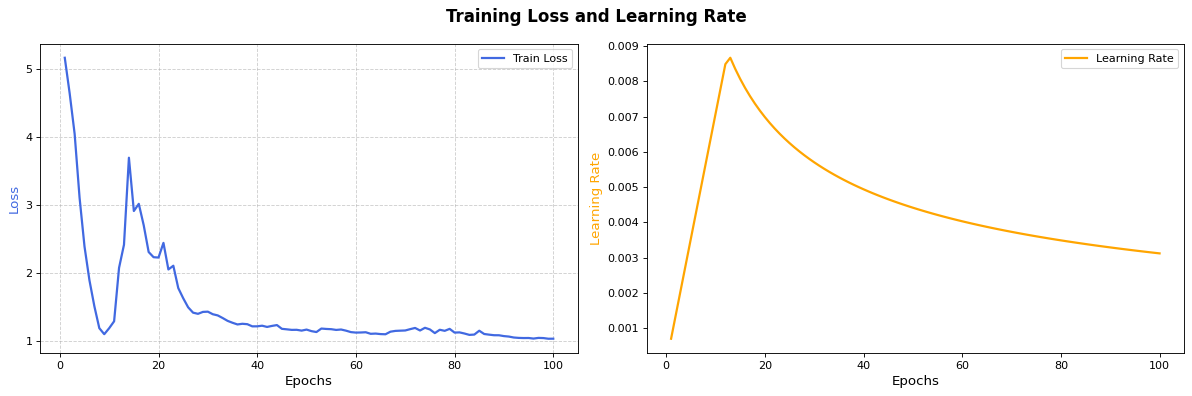

In [69]:
fig = plt.figure(figsize=(15,5), dpi=80)

# Train Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, color='royalblue', linewidth=2, label="Train Loss")
plt.ylabel("Loss", color = 'royalblue', fontsize = 12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel("Epochs", fontsize=12)
plt.legend(loc='best')

# Learning Rate
plt.subplot(1,2,2)
plt.plot(epochs, lr_history, color='orange', linewidth=2, label="Learning Rate")
plt.ylabel("Learning Rate", color='orange', fontsize=12)
plt.xlabel("Epochs", fontsize=12)
plt.legend(loc='best')

fig.suptitle("Training Loss and Learning Rate", fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 11: Model Evaluation.</div>

In [54]:
# ── Instantiate model ────────────
translator = Transformer(**vars(config))

# ── Load State dictionary ────────
ckpt_path = r"/kaggle/working/checkpoints/best_checkpoint.pt"
ckpt = load_checkpoint(path = ckpt_path, device = train_cfg.device)

# ── Load weights ────────────────
translator.load_state_dict(ckpt['model_state_dict'])
translator = translator.to(train_cfg.device)

In [55]:
print(
    f"Checkpoint Epoch: {ckpt['epoch']}\n"
    f"Checkpoint Loss: {ckpt['train_loss']:.4f}\n"
    f"Checkpoint Accuracy: {ckpt['train_acc']:.2f}%"
)

Checkpoint Epoch: 99
Checkpoint Loss: 1.0322
Checkpoint Accuracy: 92.27%


In [56]:
print("=" * 35)
print("        Vocabulary Summary")
print("=" * 35)
print(f"Source Vocabulary Size : {len(src_vocab):>5}")
print(f"Target Vocabulary Size : {len(tgt_vocab):>5}")
print("=" * 35)

        Vocabulary Summary
Source Vocabulary Size :   155
Target Vocabulary Size :   150


In [57]:
def pad_sentences(encoded_sentences: List[List[int]], pad_idx: int)-> torch.tensor:
    batch_size = len(encoded_sentences)
    
    max_seq_len = max(map(len, encoded_sentences))
    padded_tensor = torch.full(
        size = (batch_size, max_seq_len),
        dtype = torch.long,
        fill_value = pad_idx
    )

    for i, sentence in enumerate(encoded_sentences):
        padded_tensor[i, : len(sentence)]  = torch.tensor(
            sentence,
            dtype = torch.long
        )

    return padded_tensor # [B, T]

In [86]:
# test
test = [
    [5, 8, 12, 20],
    [7, 9, 14],
    [3, 6, 11, 15, 18]
]
pad_sentences(test, -1)

tensor([[ 5,  8, 12, 20, -1],
        [ 7,  9, 14, -1, -1],
        [ 3,  6, 11, 15, 18]])

In [83]:
def eval_model(
    translator: nn.Module, 
    max_len : int,
    src_path: str, 
    tgt_path: str, 
    pad_idx:  int,
    eng_sentences: List[str],
    device:torch.device)-> None:
    
    # ── Load source and target vocabularies ──
    src_vocab = Vocabulary.load(src_path)
    tgt_vocab = Vocabulary.load(tgt_path)
    
    # ── Evaluation Mode ──────
    translator.eval()

    # ── Encode and pad English sentences ──
    encoded_eng_sentences = src_vocab.encode(eng_sentences)
    padded_input = pad_sentences(encoded_eng_sentences, pad_idx)
    encoder_input = padded_input.to(device) 

    # ── Initial decoder input: <BOS> ──
    batch_size = len(eng_sentences)
    decoder_input = torch.full(
        size = (batch_size, 1),
        dtype=torch.long,
        device = device,
        fill_value = tgt_vocab.BOS_IDX,
    )
    
    print(f"Encoder Input: {encoder_input}")
    print(f"Decoder Input: {decoder_input}")
    
    with torch.inference_mode():
        for idx in range(len(encoder_input)):
            words:List[str] = []
            
            # Current sentence
            one_encoder_input = encoder_input[idx][None,:]
            one_decoder_input = decoder_input[idx][None,:]
            
            for _ in range(max_len):                
                # ── Predict next token ──
                logits = translator(one_encoder_input, one_decoder_input) #[B, T, V]
                """
                where:
                    B = 1       batch size
                    T = current decoder sequence length
                    V = 150     target vocabulary size
                """
                # Last decoder position
                predicted_token_id = torch.argmax(  
                    logits[:, -1, :], # -1     → take the LAST decoder position → [B, V]
                    dim=-1
                )
        
                # ── Stop at <EOS> ──
                if predicted_token_id.item() == tgt_vocab.EOS_IDX:
                    print(f"\nEnglish: {eng_sentences[idx]}")
                    print(f"Arabic:  {' '.join(words)}")
                    print("-" * 120)     
                    break
        
                # ── Convert token ID to word ──
                word = tgt_vocab.idx_to_word[predicted_token_id.item()]
                words.append(word)
        
                # ── Append predicted token ──
                # Take the token I just predicted and append it to the decoder's input sequence and fix shapes.
                one_decoder_input = torch.cat(
                    [one_decoder_input, predicted_token_id[:, None]],
                    dim=1
                )

In [84]:
# ── Define vocabulary file paths ──
src_path = r'/kaggle/working/Vocabulary/src_vocab.pt'
tgt_path = r'/kaggle/working/Vocabulary/tgt_vocab.pt'
eng_sentences = ["In the open fields, colorful flowers grow among the green grass and attract butterflies and bees.",
                 "Green forests stretch across the land, while small streams flow gently between the trees.",
                 "The Beauty of Nature."]

eval_model(
    translator=translator,
    max_len = config.max_seq_len,
    src_path=src_path,
    tgt_path=tgt_path,
    pad_idx = config.pad_idx,
    eng_sentences=eng_sentences,
    device=train_cfg.device
)

Encoder Input: tensor([[ 18,  19,  99, 100, 101, 102, 103, 104,  19, 105, 106,  26, 107, 108,
          26, 109],
        [ 32,  33,  34,  24,  19,  35,  36,  37,  38,  39,  40,  41,  19,  42,
           0,   0],
        [  2,   3,   4,   5,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0]], device='cuda:0')
Decoder Input: tensor([[2],
        [2],
        [2]], device='cuda:0')

English: In the open fields, colorful flowers grow among the green grass and attract butterflies and bees.
Arabic:  في الصباح الباكر، ينتشر ضوء الشمس فوق الجبال ويمنح السماء لونًا ذهبيًا دافئًا.
------------------------------------------------------------------------------------------------------------------------

English: Green forests stretch across the land, while small streams flow gently between the trees.
Arabic:  للطبيعة جمال هادئ يمكن العثور عليه في أماكن كثيرة.
------------------------------------------------------------------------------------------------------------------------


# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 12: Error Analysis.</div>

## **Step 12.1: Inspect the Training Pair.**


| Step | Result |
|---|---|
| Inspect the 4th training pair | Successfully retrieved and decoded the English source sentence and its corresponding Arabic target translation. |

In [75]:
# ── Inspect the fourth training pair ──
source_ids, target_ids = translation_dataset[3]

source_sentence = src_vocab.decode([source_ids])
target_sentence = tgt_vocab.decode([target_ids])

print("English:")
print(source_sentence)

print("\nArabic:")
print(target_sentence)

English:
['Green forests stretch across the land, while small streams flow gently between the trees.']

Arabic:
['تمتد الغابات الخضراء عبر الأرض، بينما تتدفق الجداول الصغيرة بهدوء بين الأشجار.']


## **Step 12.2: Teacher-Forced Evaluation**

> Evaluate the model on the same training pair using teacher forcing and compare the predicted target tokens with the expected next tokens.

| Step | Result |
|---|---|
| Teacher-Forced Evaluation | The model predicted all target tokens correctly. The prediction exactly matches the target, including the `<EOS>` token. |

In [74]:
# Now let's perform teacher-forced evaluation on this exact training example.

# ── Get the second training pair ──
source_ids, target_ids = translation_dataset[1]

# ── Prepare source (English) sequence ──
encoder_input = torch.tensor(
    [source_ids],
    dtype=torch.long,
    device=train_cfg.device
)

# ── Prepare target (Arabic) sequence ──
target_tensor = torch.tensor(
    [target_ids],
    dtype=torch.long,
    device=train_cfg.device
)

# ── Teacher-forcing input ──
decoder_input = target_tensor[:, :-1]

# ── Expected next tokens ──
target_output = target_tensor[:, 1:]

# ── Run the trained model ──
with torch.inference_mode():
    logits = translator(
        encoder_input,
        decoder_input
    )

# ── Get predicted token IDs ──
predictions = logits.argmax(dim=-1)

print("Source:     ", encoder_input)
print("Target:     ", target_output)
print("Prediction: ", predictions)

Source:      tensor([[ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17]], device='cuda:0')
Target:      tensor([[ 6,  4,  7,  8,  9, 10, 11, 12, 13,  3]], device='cuda:0')
Prediction:  tensor([[ 6,  4,  7,  8,  9, 10, 11, 12, 13,  3]], device='cuda:0')


## **Step 12.3: Analyze First-Token Prediction**
* The purpose is:   
   * Compare the target first Arabic token with the model's first predicted token for every training sentence.

> | Step | Result |
|---|---|
| First-Token Prediction Analysis | The model correctly predicts the first token for 5 of 15 training sentences, while several incorrect predictions repeatedly favor common tokens such as `في` and `للطبيعة`. This indicates that the model's initial autoregressive prediction is a major source of error. |

* **Analysis:**   
The decoder receives only `<BOS>`, so it must predict the first Arabic token without previous Arabic context. The model correctly predicts 5/15 first tokens, but often predicts common tokens such as `في`, showing difficulty choosing the correct first word from the English sentence alone.

In [78]:
# ── Test first-token prediction for every training sentence ──
translator.eval()

with torch.inference_mode():

    for index in range(len(translation_dataset)):

        # ── Get source and target IDs ──
        source_ids, target_ids = translation_dataset[index]

        # ── Prepare source sequence ──
        encoder_input = torch.tensor(
            [source_ids],
            dtype=torch.long,
            device=train_cfg.device
        )

        # ── Prepare target sequence ──
        target_tensor = torch.tensor(
            [target_ids],
            dtype=torch.long,
            device=train_cfg.device
        )

        # ── Use only <BOS> as decoder input ──
        decoder_input = target_tensor[:, :1]

        # ── Run model ──
        logits = translator(
            encoder_input,
            decoder_input
        )

        # ── First predicted token ──
        predicted_id = logits[:, -1, :].argmax(dim=-1).item()

        # ── Correct first token ──
        target_id = target_tensor[:, 1].item()

        # ── Convert IDs to words ──
        predicted_word = tgt_vocab.idx_to_word[predicted_id]
        target_word = tgt_vocab.idx_to_word[target_id]

        print(
            f"{index:2d} | "
            f"Target: {target_word:<15} | "
            f"Predicted: {predicted_word:<15} | "
            f"{'✓' if predicted_id == target_id else '✗'}"
        )

 0 | Target: جمال            | Predicted: جمال            | ✓
 1 | Target: للطبيعة         | Predicted: للطبيعة         | ✓
 2 | Target: في              | Predicted: للطبيعة         | ✗
 3 | Target: تمتد            | Predicted: للطبيعة         | ✗
 4 | Target: تملأ            | Predicted: في              | ✗
 5 | Target: في              | Predicted: في              | ✓
 6 | Target: تتحرك           | Predicted: في              | ✗
 7 | Target: بالقرب          | Predicted: في              | ✗
 8 | Target: ترتفع           | Predicted: في              | ✗
 9 | Target: في              | Predicted: في              | ✓
10 | Target: خلال            | Predicted: في              | ✗
11 | Target: عند             | Predicted: في              | ✗
12 | Target: تسطع            | Predicted: في              | ✗
13 | Target: في              | Predicted: في              | ✓
14 | Target: تذكرنا          | Predicted: في              | ✗


## **Step 12.4: Autoregressive Prediction Analysis**

**Analysis:**    
* The model generates the first two training sentences correctly, but for many later sentences it produces a complete translation from another training example instead of translating the given source sentence.
* This shows that autoregressive generation can fail even when teacher-forced predictions are correct, indicating that the model is not reliably conditioning its generated sequence on the source sentence.

In [85]:
# ── Test autoregressive prediction for every training sentence ──
translator.eval()

with torch.inference_mode():

    for index in range(len(translation_dataset)):

        # ── Get source and target IDs ──
        source_ids, target_ids = translation_dataset[index]

        # ── Prepare source sequence ──
        encoder_input = torch.tensor(
            [source_ids],
            dtype=torch.long,
            device=train_cfg.device
        )

        # ── Start decoder with <BOS> ──
        decoder_input = torch.tensor(
            [[tgt_vocab.BOS_IDX]],
            dtype=torch.long,
            device=train_cfg.device
        )

        # ── Generate translation ──
        for _ in range(config.max_seq_len):

            logits = translator(
                encoder_input,
                decoder_input
            )

            # ── Predict next token ──
            predicted_id = logits[:, -1, :].argmax(dim=-1)

            # ── Stop at <EOS> ──
            if predicted_id.item() == tgt_vocab.EOS_IDX:
                break

            # ── Append predicted token ──
            decoder_input = torch.cat(
                [decoder_input, predicted_id[:, None]],
                dim=1
            )

        # ── Decode target and prediction ──
        target_sentence = tgt_vocab.decode([target_ids])[0]
        predicted_sentence = tgt_vocab.decode(
            [decoder_input[0].tolist()]
        )[0]

        print(f"\n{'=' * 100}")
        print(f"Index:      {index}")
        print(f"Target:     {target_sentence}")
        print(f"Prediction: {predicted_sentence}")


Index:      0
Target:     جمال الطبيعة.
Prediction: جمال الطبيعة.

Index:      1
Target:     للطبيعة جمال هادئ يمكن العثور عليه في أماكن كثيرة.
Prediction: للطبيعة جمال هادئ يمكن العثور عليه في أماكن كثيرة.

Index:      2
Target:     في الصباح الباكر، ينتشر ضوء الشمس فوق الجبال ويمنح السماء لونًا ذهبيًا دافئًا.
Prediction: للطبيعة جمال هادئ يمكن العثور عليه في أماكن كثيرة.

Index:      3
Target:     تمتد الغابات الخضراء عبر الأرض، بينما تتدفق الجداول الصغيرة بهدوء بين الأشجار.
Prediction: للطبيعة جمال هادئ يمكن العثور عليه في أماكن كثيرة.

Index:      4
Target:     تملأ الطيور الهواء بأغانيها، ويداعب نسيم لطيف أوراق الأشجار.
Prediction: في الصباح الباكر، ينتشر ضوء الشمس فوق الجبال ويمنح السماء لونًا ذهبيًا دافئًا.

Index:      5
Target:     في أعماق الغابة، تصنع الأشجار العالية ظلالًا باردة تجد فيها العديد من الحيوانات مأوى.
Prediction: في أعماق الغابة، تصنع الأشجار العالية ظلالًا باردة تجد فيها العديد من الحيوانات مأوى.

Index:      6
Target:     تتحرك بعض الحيوانات بهدوء بين الأغصان

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Step 13: Experiments.</div>

## **Experiments**

Multiple experiments were conducted by modifying the Transformer configuration to investigate the effect of different hyperparameters and training settings on model performance. For each experiment, the configuration was updated in the configuration file, the model was retrained, and the training behavior and evaluation results were recorded for comparison.


In [ ]:
# ex: 1
# batch_size     = 2
# d_model        = 512
# expansion_dim  = 2048
# num_heads      = 8
# num_layers     = 6
# max_seq_len    = 100
# epochs         = 100
# warmup_steps   = 4000

# Epoch [ 10] - Train loss: 4.260 | Train acc: 12.371% | LR: 0.000014
# Epoch [ 20] - Train loss: 2.111 | Train acc: 91.753% | LR: 0.000028
# Epoch [ 30] - Train loss: 1.038 | Train acc: 99.485% | LR: 0.000042
# Epoch [ 40] - Train loss: 0.872 | Train acc: 100.000% | LR: 0.000056
# Epoch [ 50] - Train loss: 0.853 | Train acc: 100.000% | LR: 0.000070
# Epoch [ 60] - Train loss: 0.854 | Train acc: 100.000% | LR: 0.000084
# Epoch [ 70] - Train loss: 0.882 | Train acc: 99.485% | LR: 0.000098
# Epoch [ 80] - Train loss: 0.862 | Train acc: 100.000% | LR: 0.000112
# Epoch [ 90] - Train loss: 0.863 | Train acc: 100.000% | LR: 0.000126
# Epoch [100] - Train loss: 0.854 | Train acc: 100.000% | LR: 0.000140
# Best checkpoint saved — Epoch: 93 | Loss: 0.8484

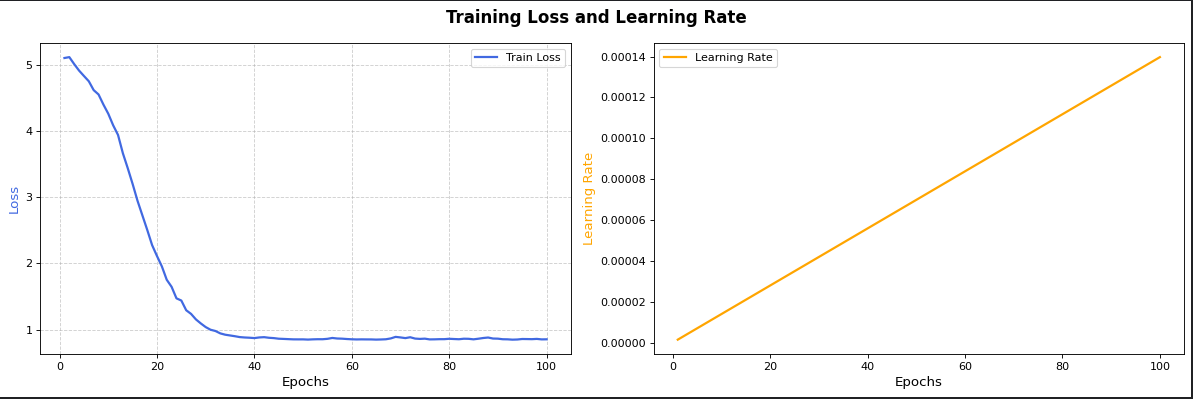

In [ ]:
# ex: 2
# batch_size     = 2
# d_model        = 512
# expansion_dim  = 2048
# num_heads      = 8
# num_layers     = 6
# epochs         = 100
# max_seq_len    = 100
# warmup_steps   = 100

# Epoch [ 10] - Train loss: 5.193 | Train acc: 7.732% | LR: 0.003536
# Epoch [ 20] - Train loss: 4.943 | Train acc: 7.732% | LR: 0.003494
# Epoch [ 30] - Train loss: 4.895 | Train acc: 7.732% | LR: 0.002853
# Epoch [ 40] - Train loss: 4.887 | Train acc: 7.732% | LR: 0.002471
# Epoch [ 50] - Train loss: 4.865 | Train acc: 7.732% | LR: 0.002210
# Epoch [ 60] - Train loss: 4.861 | Train acc: 7.732% | LR: 0.002017
# Epoch [ 70] - Train loss: 4.832 | Train acc: 7.732% | LR: 0.001868
# Epoch [ 80] - Train loss: 4.822 | Train acc: 7.732% | LR: 0.001747
# Epoch [ 90] - Train loss: 4.828 | Train acc: 7.732% | LR: 0.001647
# Epoch [100] - Train loss: 4.824 | Train acc: 7.732% | LR: 0.001563
# Best checkpoint saved — Epoch: 5 | Loss: 4.1519

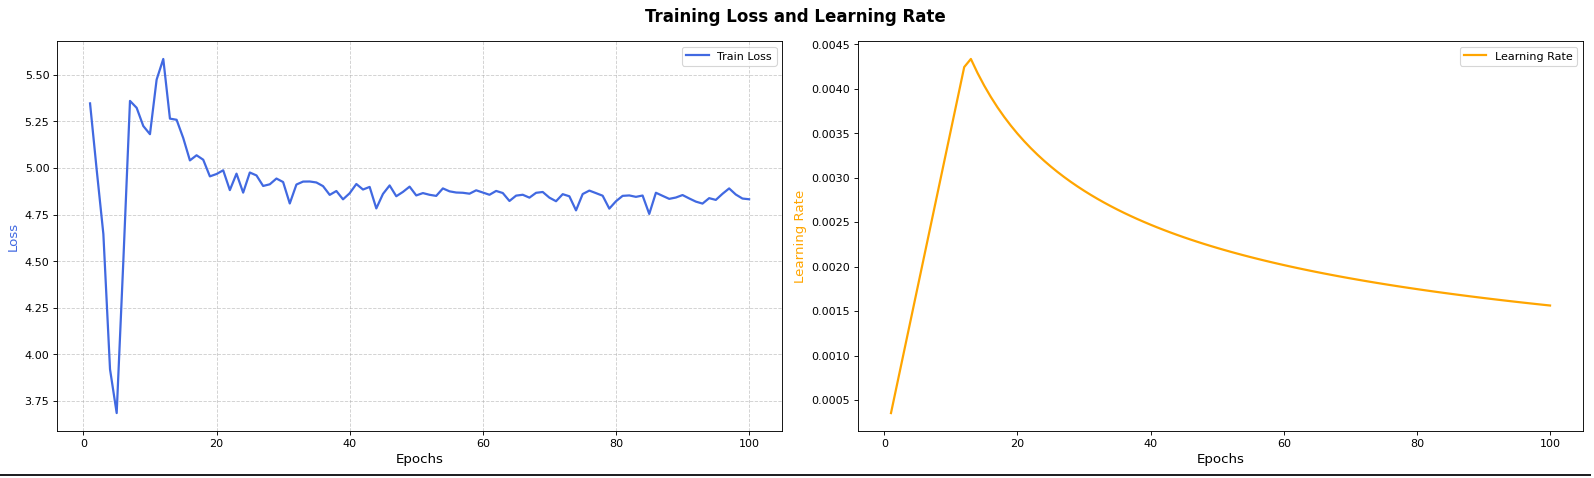

In [ ]:
# ex: 3
# batch_size     = 2
# d_model        = 128
# expansion_dim  = 512
# num_heads      = 4
# num_layers     = 2
# max_seq_len    = 32
# epochs         = 100
# warmup_steps   = 100

# Epoch [ 10] - Train loss: 1.079 | Train acc: 96.392% | LR: 0.007071
# Epoch [ 20] - Train loss: 2.340 | Train acc: 55.155% | LR: 0.006988
# Epoch [ 30] - Train loss: 1.441 | Train acc: 85.567% | LR: 0.005705
# Epoch [ 40] - Train loss: 1.188 | Train acc: 92.268% | LR: 0.004941
# Epoch [ 50] - Train loss: 1.123 | Train acc: 92.784% | LR: 0.004419
# Epoch [ 60] - Train loss: 1.122 | Train acc: 92.784% | LR: 0.004034
# Epoch [ 70] - Train loss: 1.137 | Train acc: 92.268% | LR: 0.003735
# Epoch [ 80] - Train loss: 1.109 | Train acc: 90.722% | LR: 0.003494
# Epoch [ 90] - Train loss: 1.072 | Train acc: 92.268% | LR: 0.003294
# Epoch [100] - Train loss: 1.054 | Train acc: 92.784% | LR: 0.003125
# Best checkpoint saved — Epoch: 95 | Loss: 1.0525

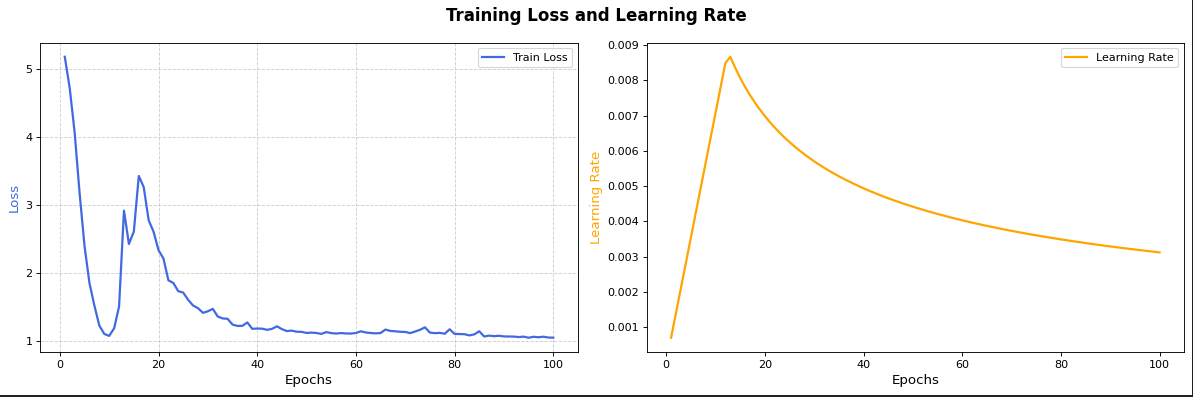

In [ ]:
# ex: 4
# batch_size     = 2
# d_model        = 512
# expansion_dim  = 2048
# num_heads      = 8
# num_layers     = 6
# print_every    = 50
# epochs         = 700
# max_seq_len    = 100
# warmup_steps   = 4000

# Epoch [ 50] - Train loss: 0.862 | Train acc: 100.000% | LR: 0.000070
# Epoch [100] - Train loss: 0.855 | Train acc: 100.000% | LR: 0.000140
# Epoch [150] - Train loss: 0.848 | Train acc: 100.000% | LR: 0.000210
# Epoch [200] - Train loss: 0.837 | Train acc: 100.000% | LR: 0.000280
# Epoch [250] - Train loss: 0.847 | Train acc: 100.000% | LR: 0.000349
# Epoch [300] - Train loss: 1.219 | Train acc: 97.938% | LR: 0.000419
# Epoch [350] - Train loss: 0.934 | Train acc: 96.392% | LR: 0.000489
# Epoch [400] - Train loss: 1.041 | Train acc: 92.268% | LR: 0.000559
# Epoch [450] - Train loss: 1.094 | Train acc: 91.237% | LR: 0.000629
# Epoch [500] - Train loss: 1.318 | Train acc: 86.598% | LR: 0.000699
# Epoch [550] - Train loss: 1.248 | Train acc: 87.113% | LR: 0.000666
# Epoch [600] - Train loss: 1.055 | Train acc: 92.268% | LR: 0.000638
# Epoch [650] - Train loss: 1.301 | Train acc: 88.144% | LR: 0.000613
# Epoch [700] - Train loss: 2.067 | Train acc: 65.979% | LR: 0.000591
# Best checkpoint saved — Epoch: 324 | Loss: 0.8282

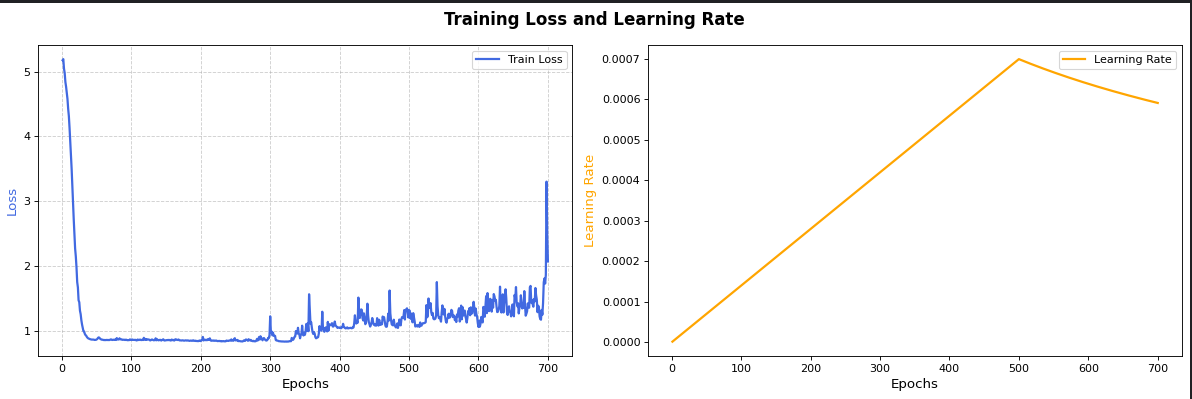

# <a id="Import"></a><div style="background: linear-gradient(to right, #1b5e20, #2e7d32, #388e3c, #43a047, #4caf50); font-family: 'Times New Roman', serif; font-size: 28px; font-weight: bold; text-align: center; border-radius: 15px; padding: 15px; border: 2px solid #ffffff; box-shadow: 0 4px 10px rgba(0, 0, 0, 0.2); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Thanks & Upvote ❤️</div>